#### imports & setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import LinearSegmentedColormap

from hub_config import RSV_HUB as HUB
import src.plotting as P

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

In [2]:
# Location scope
# Toggle to include / exclude jurisdiction from ALL analyses
EXCLUDE_NATIONAL    = True   # US national-level aggregate
EXCLUDE_PUERTO_RICO = False  # Puerto Rico (FIPS 72)

EXCLUDE_LOCS = (
    (["US"] if EXCLUDE_NATIONAL    else []) +
    (["72"] if EXCLUDE_PUERTO_RICO else [])
)
print(f"Excluding locations: {EXCLUDE_LOCS or 'none'}")

Excluding locations: ['US']


In [12]:
scores_all = pd.read_parquet(HUB.scores_path)
scores = scores_all[
    (scores_all["horizon"] != -1) &
    (~scores_all["location"].isin(EXCLUDE_LOCS))
].copy()

# Task space
ALL_DATES    = sorted(scores["reference_date"].unique())
ALL_HORIZONS = sorted(scores["horizon"].unique())    # [0, 1, 2, 3]
ALL_LOCS     = sorted(scores["location"].unique())

N_DATES, N_HORIZONS, N_LOCS = len(ALL_DATES), len(ALL_HORIZONS), len(ALL_LOCS)

_scoreable = scores.groupby(["reference_date", "horizon", "location"]).size()
MAX_TASKS   = len(_scoreable)
SCOREABLE_DH = scores.groupby(["reference_date", "horizon"]).ngroups

ELIGIBILITY_THRESHOLD = 0.80
ENSEMBLE   = HUB.ensemble_id
BASELINE   = HUB.baseline_id
GOOGLE     = HUB.google_id
HUB_MODELS = set(HUB.hub_model_ids)   # ensemble + baseline + extra ensembles


In [20]:
# Colour scheme
# Google = pink, hub models (ensemble, baseline, extra ensembles) = black, all others = grey
GREEN = "#17b248"
GOOGLE_PINK = "#e91e8c"
ALL_MODELS  = sorted(scores["model_id"].unique())
HUB_BLACK = "#000000"
OTHER_GREY = "#9a9a9a"
MODEL_COLOUR = {
    m: (
        GOOGLE_PINK if m == GOOGLE
        else HUB_BLACK if m in HUB_MODELS
        else OTHER_GREY
    )
    for m in scores["model_id"].unique()
}


In [ ]:
# Location submission check (here for Puerto Rico)
# Uses scores_all (before location filtering) -- how many models submit for this location?
CHECK_LOCATION = "72"  # Puerto Rico FIPS code
_loc  = scores_all[(scores_all["horizon"] != -1) & (scores_all["location"] == CHECK_LOCATION)]
_all = scores_all[ scores_all["horizon"] != -1]

if _loc.empty:
    print(f"{CHECK_LOCATION} has no scored tasks in this hub/season.")
else:
    _loc_count  = _loc.groupby("model_id").size().rename("Location tasks")
    _tot_count = _all.groupby("model_id").size().rename("Total tasks")
    _df = pd.concat([_loc_count, _tot_count], axis=1).fillna(0).astype(int)
    _df["% of own tasks"] = _df["Location tasks"] / _df["Total tasks"]
    _df = _df.sort_values("Location tasks", ascending=False)

    print(f"Location ({CHECK_LOCATION}) scored tasks : {len(_loc):,}  over {_loc['reference_date'].nunique()} reference dates")
    print(f"Models with location ({CHECK_LOCATION}) present : {(_df['Location tasks'] > 0).sum()} / {len(_df)}")
    display(
        _df.style
        .format({f"% of own tasks": "{:.1%}"})
        .background_gradient(subset=["Location tasks"], cmap="YlOrRd")
    )

Location (72) scored tasks : 136  over 10 reference dates
Models with location (72) present : 4 / 7


,Location tasks,Total tasks,% of own tasks
model_id,,,
CEPH-Rtrend_rsv,34,1802,1.9%
Google_SAI-RSVEns,34,1768,1.9%
RSVHub-baseline,34,1802,1.9%
RSVHub-ensemble,34,1802,1.9%
CFA_Pyrenew-Pyrenew_HE_RSV,0,957,0.0%
CFA_Pyrenew-Pyrenew_H_RSV,0,978,0.0%
UM-DeepOutbreak,0,390,0.0%


## RSVHub Analysis: Current Season Performance

This notebook evaluates performance of models currently submitting to the CDC's RSV Forecast Hub for target weekly incident RSV hospital admissions. For this analysis, we examine only the current season from January to May 2026. The inputs are quantile forecasts, and we examine 52 jurisdictions (50 states + Washington, DC + Puerto Rico). National-level (US) forecasts are excluded. Forecasts are submitted for horizons $[-1, 3]$, but this analysis excludes horizon $-1$.

The two main evaluation metrics are Weighted Interval Score (WIS) and log WIS (the same WIS scoring function applied to log transformed data), calculated in the same way as currently done for the CDC's own evaluations.

Main model comparisons consider only those models submitting for at least 80% of eligible forecasting tasks, where the task space is defined over the required combination of location, reference date and prediction horizon, i.e., `one forecast task = one model x one reference date x one horizon x one location`. For each task, the submitted quantile forecast is compared against the current observed hospital admissions for the corresponding `target_end_date`.

## Eligibility

In [18]:
model_n_tasks = scores.groupby("model_id").size().rename("n_tasks")
eligible_models = sorted(
    model_n_tasks[model_n_tasks / MAX_TASKS >= ELIGIBILITY_THRESHOLD].index
)

print(f"Task space: {N_DATES} dates × {N_HORIZONS} horizons × {N_LOCS} locs = {MAX_TASKS:,} max tasks/model")
print(f"Eligibility threshold: ≥{ELIGIBILITY_THRESHOLD:.0%}  (≥{int(ELIGIBILITY_THRESHOLD * MAX_TASKS):,} tasks)")
print(f"Eligible models: {len(eligible_models)}")

_pr_tasks = (
    scores_all[(scores_all["horizon"] != -1) & (scores_all["location"] == "72")]
    .groupby("model_id").size()
    .rename("pr_tasks")
)

_elig_tbl = pd.DataFrame({
    "Tasks":   model_n_tasks[eligible_models],
    "Tasks %": model_n_tasks[eligible_models] / MAX_TASKS,
}).join(_pr_tasks).fillna(0)
_elig_tbl["pr_tasks"] = _elig_tbl["pr_tasks"].astype(int)

display(
    _elig_tbl
    .rename(columns={"pr_tasks": "PR tasks"})
    .style
    .format({"Tasks": "{:,}", "Tasks %": "{:.1%}", "PR tasks": "{:,}"})
    .background_gradient(subset=["PR tasks"], cmap="YlOrRd")
)

Task space: 10 dates × 4 horizons × 52 locs = 1,768 max tasks/model
Eligibility threshold: ≥80%  (≥1,414 tasks)
Eligible models: 4


,Tasks,Tasks %,PR tasks
model_id,,,
CEPH-Rtrend_rsv,"1,768",100.0%,34
Google_SAI-RSVEns,"1,768",100.0%,34
RSVHub-baseline,"1,768",100.0%,34
RSVHub-ensemble,"1,768",100.0%,34


## Coverage

In [21]:
cov = (
    scores.groupby("model_id", as_index=False)
    .agg(
        n_ref_dates=("reference_date", "nunique"),
        n_horizons=("horizon", "nunique"),
        n_locations=("location", "nunique"),
        n_tasks=("wis", "size"),
    )
)

# Number of unique (reference_date × horizon) combinations submitted per model
n_dh = (
    scores.groupby(["model_id", "reference_date", "horizon"])
    .size()
    .groupby("model_id")
    .size()
    .rename("n_dh_combos")
    .reset_index()
)
cov = cov.merge(n_dh, on="model_id")

cov["pct_ref_dates"]   = cov["n_ref_dates"] / N_DATES
cov["pct_dh_combos"]   = cov["n_dh_combos"] / SCOREABLE_DH   # denominator = scoreable pairs only
cov["pct_tasks"]       = cov["n_tasks"]      / MAX_TASKS
cov["eligible"]        = cov["model_id"].isin(eligible_models).map({True: "Yes", False: "No"})

cov_display = (
    cov[[
        "model_id", "n_ref_dates", "pct_ref_dates",
        "n_horizons",
        "n_dh_combos", "pct_dh_combos",
        "n_locations", "pct_tasks", "n_tasks", "eligible",
    ]]
    .rename(columns={
        "model_id":       "Model",
        "n_ref_dates":    "Ref dates",
        "pct_ref_dates":  "Ref dates %",
        "n_horizons":     "Horizons",
        "n_dh_combos":    "Date×horizon",
        "pct_dh_combos":  "Date×horizon %",
        "n_locations":    "Locations",
        "pct_tasks":      "Tasks %",
        "n_tasks":        "Tasks",
        "eligible":       "Eligible",
    })
    .sort_values("Tasks %", ascending=False)
)

display(
    cov_display.style
    .format({"Ref dates %": "{:.1%}", "Date×horizon %": "{:.1%}", "Tasks %": "{:.1%}"})
    .hide(axis="index")
        .apply(
        lambda s: [f"color: {GOOGLE_PINK}; font-weight: bold"
                   if v == GOOGLE else "" for v in s],
        subset=["Model"], axis=0,
    )
    .apply(
        lambda s: [f"color: {GREEN}; font-weight: bold"
                   if v == "Yes" else "" for v in s],
        subset=["Eligible"], axis=0,
    )
)

Model,Ref dates,Ref dates %,Horizons,Date×horizon,Date×horizon %,Locations,Tasks %,Tasks,Eligible
CEPH-Rtrend_rsv,10,100.0%,4,34,100.0%,52,100.0%,1768,Yes
Google_SAI-RSVEns,10,100.0%,4,34,100.0%,52,100.0%,1768,Yes
RSVHub-baseline,10,100.0%,4,34,100.0%,52,100.0%,1768,Yes
RSVHub-ensemble,10,100.0%,4,34,100.0%,52,100.0%,1768,Yes
CFA_Pyrenew-Pyrenew_H_RSV,10,100.0%,2,19,55.9%,51,54.2%,959,No
CFA_Pyrenew-Pyrenew_HE_RSV,10,100.0%,2,19,55.9%,50,53.1%,938,No
UM-DeepOutbreak,9,90.0%,4,30,88.2%,12,20.4%,360,No


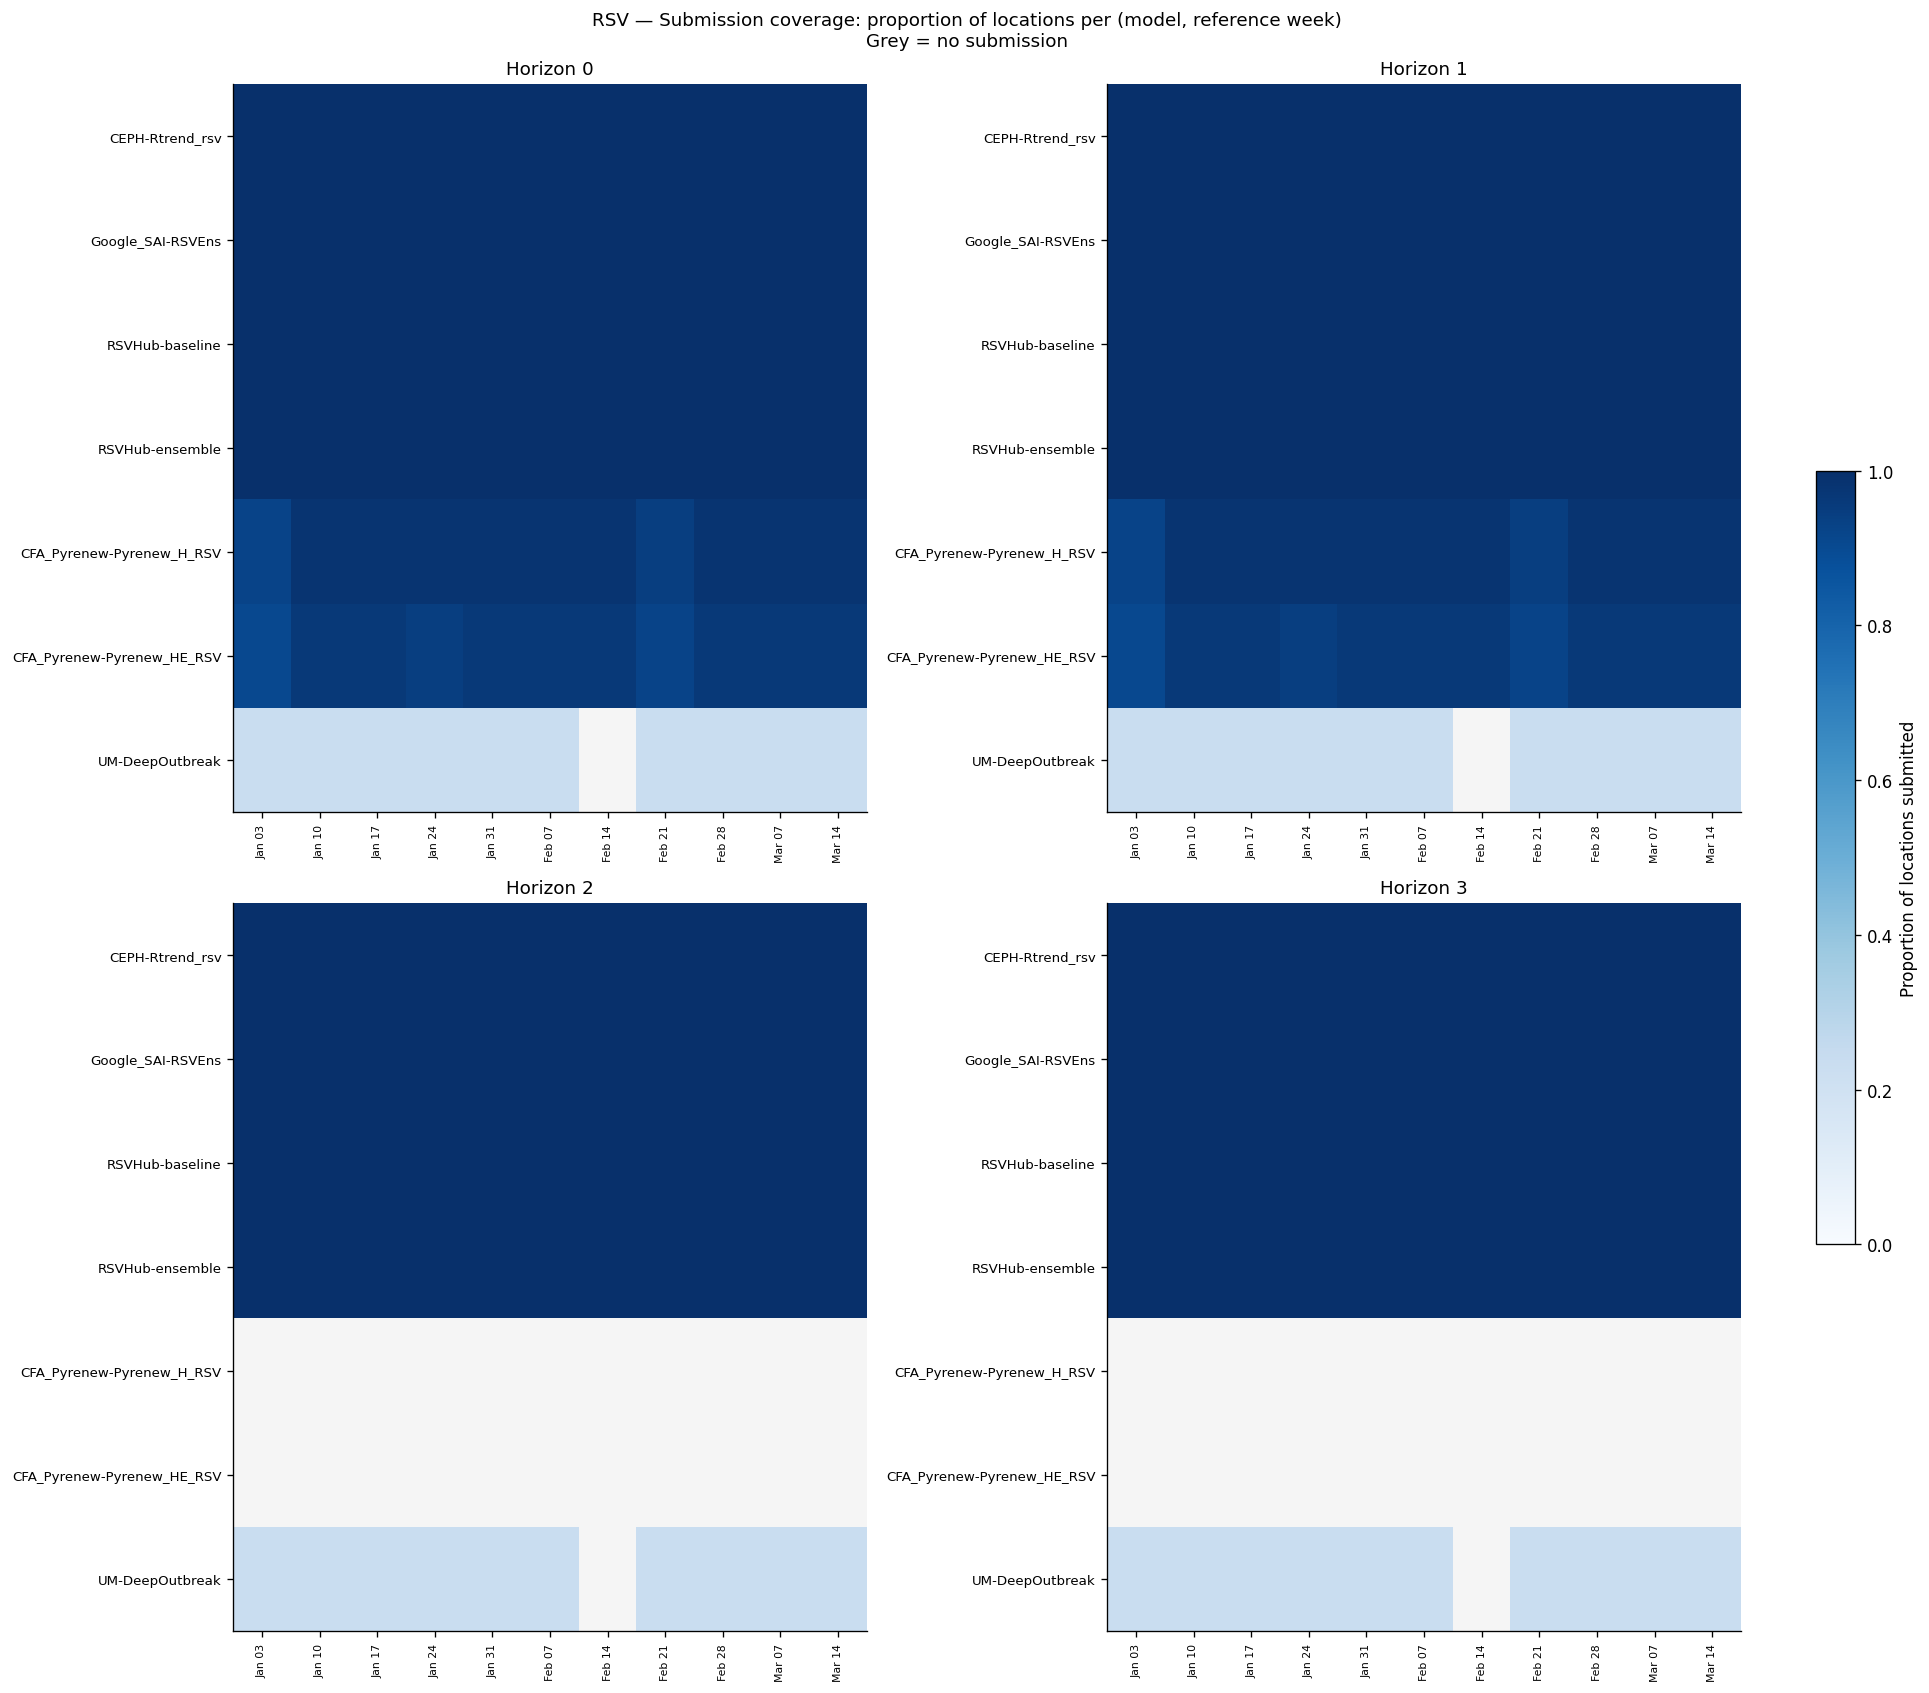

In [ ]:
# Heatmap: proportion of locations submitted per (model, week, horizon)
# Built from FORECASTS (not scores) so the heatmap shows what was actually
# submitted, independent of whether truth data is available yet.

forecasts_hm = pd.read_parquet(HUB.forecasts_path)
forecasts_hm = forecasts_hm[
    (forecasts_hm["target"]  == HUB.target_name) &
    (forecasts_hm["horizon"] != -1) &
    (~forecasts_hm["location"].isin(EXCLUDE_LOCS))  # match location scope set above
]

ALL_DATES_HM = sorted(forecasts_hm["reference_date"].dropna().unique())

loc_cov = (
    forecasts_hm.groupby(["model_id", "reference_date", "horizon"])["location"]
    .nunique()
    .div(N_LOCS)
    .reset_index(name="prop_locs")
)

model_order = cov.sort_values("n_tasks", ascending=False)["model_id"].tolist()

P.plot_coverage_heatmap(loc_cov, model_order, ALL_DATES_HM, ALL_HORIZONS, N_LOCS, HUB.label)

## Season Average Comparison

Model,Tasks,Mean WIS,Median WIS,Mean log WIS,Median log WIS,50% coverage,95% coverage,Rel. WIS
RSVHub-baseline,1768,20.50,11.83,0.2682,0.1897,30.4%,91.7%,0.86
Google_SAI-RSVEns,1768,20.59,9.71,0.1989,0.1329,36.1%,82.5%,0.86
RSVHub-ensemble,1768,23.91,10.92,0.2329,0.1575,37.9%,85.3%,1.00
CEPH-Rtrend_rsv,1768,29.08,12.19,0.2726,0.1772,33.5%,74.2%,1.22


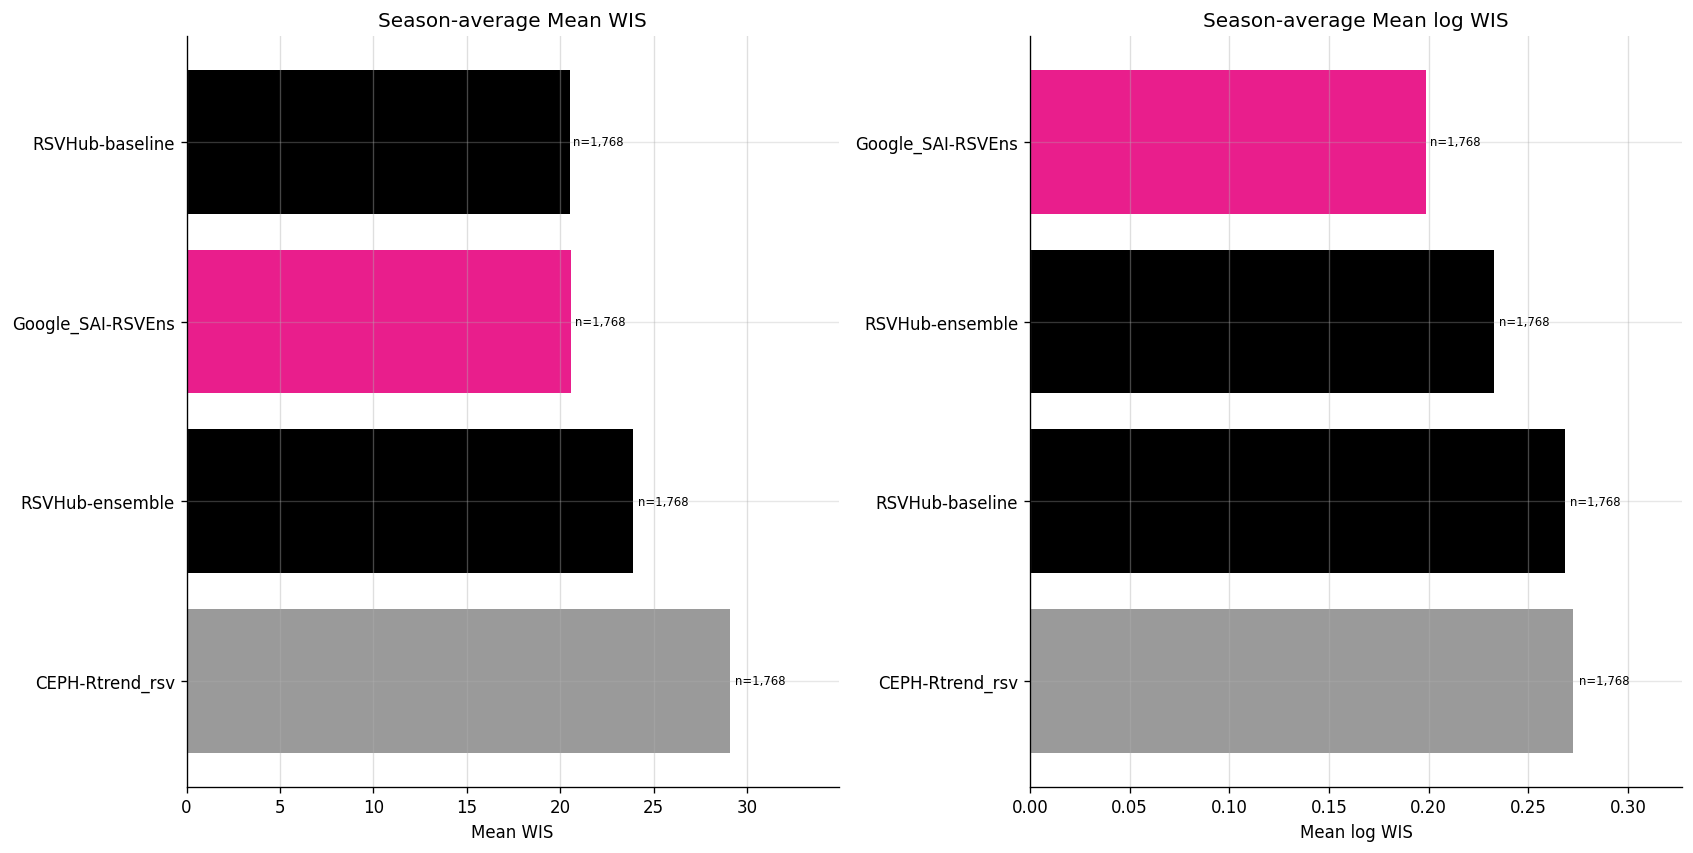

In [22]:
elig = scores[scores["model_id"].isin(set(eligible_models) | HUB_MODELS)]

summary = (
    elig.groupby("model_id", as_index=False)
    .agg(
        n_tasks        = ("wis",     "size"),
        mean_wis       = ("wis",     "mean"),
        median_wis     = ("wis",     "median"),
        mean_log_wis   = ("log_wis", "mean"),
        median_log_wis = ("log_wis", "median"),
        cov_50         = ("cov_50",  "mean"),
        cov_95         = ("cov_95",  "mean"),
    )
    .sort_values("mean_wis")
)

_ens_row = summary[summary["model_id"] == ENSEMBLE]
_ensemble_wis = _ens_row["mean_wis"].values[0] if len(_ens_row) else float("nan")
summary["rel_wis"] = summary["mean_wis"] / _ensemble_wis

# Diverging colormap: green (< 1) → white (= 1, ensemble) → orange → red (> 1)
_cmap_rel = LinearSegmentedColormap.from_list(
    "rel_wis",
    [(0.00, "#1a9850"), (0.50, "white"), (0.75, "#fc8d59"), (1.00, "#d73027")]
)
# white on 1 for ensemble 
_d = max(abs(summary["rel_wis"].dropna() - 1.0).max(), 0.01)

_summary_display = summary.rename(columns={
    "model_id":        "Model",
    "n_tasks":         "Tasks",
    "mean_wis":        "Mean WIS",
    "median_wis":      "Median WIS",
    "mean_log_wis":    "Mean log WIS",
    "median_log_wis":  "Median log WIS",
    "rel_wis":         "Rel. WIS",
    "cov_50":          "50% coverage",
    "cov_95":          "95% coverage",
})

display(
    _summary_display.style
    .format({
        "Mean WIS":        "{:.2f}",
        "Median WIS":      "{:.2f}",
        "Mean log WIS":    "{:.4f}",
        "Median log WIS":  "{:.4f}",
        "Rel. WIS":        "{:.2f}",
        "50% coverage":    "{:.1%}",
        "95% coverage":    "{:.1%}",
    })
    .background_gradient(subset=["Mean WIS"],     cmap="RdYlGn_r", axis=0)
    .background_gradient(subset=["Mean log WIS"], cmap="RdYlGn_r", axis=0)
    .background_gradient(subset=["Rel. WIS"],     cmap=_cmap_rel,
                         vmin=1.0 - _d, vmax=1.0 + _d, axis=0)
    .apply(
        lambda s: [f"color: {GOOGLE_PINK}; font-weight: bold"
                   if v == GOOGLE else "" for v in s],
        subset=["Model"], axis=0,
    )
    .hide(axis="index")
)

P.plot_season_bars(summary, MODEL_COLOUR)


## WIS vs logWIS

In [23]:
all_summary = (
    scores.groupby("model_id", as_index=False)
    .agg(
        mean_wis     = ("wis",     "mean"),
        mean_log_wis = ("log_wis", "mean"),
        n_tasks      = ("wis",     "size"),
    )
)
all_summary["is_eligible"] = all_summary["model_id"].isin(eligible_models)

# P.plot_wis_vs_logwis(all_summary, MODEL_COLOUR, ELIGIBILITY_THRESHOLD)

# Rank comparison (eligible models only)
rank_tbl = (
    all_summary[all_summary["is_eligible"]]
    [["model_id", "mean_wis", "mean_log_wis"]]
    .copy()
)
rank_tbl["wis_rank"]     = rank_tbl["mean_wis"].rank(method="min").astype(int)
rank_tbl["log_wis_rank"] = rank_tbl["mean_log_wis"].rank(method="min").astype(int)
rank_tbl["rank_diff"]    = rank_tbl["log_wis_rank"] - rank_tbl["wis_rank"]
rank_tbl = rank_tbl.sort_values("wis_rank")

display(
    rank_tbl[["model_id","mean_wis","wis_rank","mean_log_wis","log_wis_rank","rank_diff"]]
    .rename(columns={
        "model_id":       "Model",
        "mean_wis":       "Mean WIS",
        "wis_rank":       "WIS rank",
        "mean_log_wis":   "Mean log WIS",
        "log_wis_rank":   "log WIS rank",
        "rank_diff":      "Rank diff (log − WIS)",
    })
    .style
    .format({"Mean WIS": "{:.2f}", "Mean log WIS": "{:.4f}"})
    .background_gradient(
        subset=["Rank diff (log − WIS)"], cmap="RdBu_r",
        vmin=-rank_tbl["rank_diff"].abs().max(),
        vmax= rank_tbl["rank_diff"].abs().max(),
    )
    .apply(
        lambda s: [f"color: {GOOGLE_PINK}; font-weight: bold"
                   if v == GOOGLE else "" for v in s],
        subset=["Model"], axis=0,
    )
    .hide(axis="index")
)

Model,Mean WIS,WIS rank,Mean log WIS,log WIS rank,Rank diff (log − WIS)
RSVHub-baseline,20.50,1,0.2682,3,2
Google_SAI-RSVEns,20.59,2,0.1989,1,-1
RSVHub-ensemble,23.91,3,0.2329,2,-1
CEPH-Rtrend_rsv,29.08,4,0.2726,4,0


## Performance by Horizon

Mean WIS by model and horizon:


horizon,0,1,2,3
model_id,,,,
RSVHub-baseline,16.83,19.33,22.02,25.51
Google_SAI-RSVEns,14.84,19.01,23.41,27.61
RSVHub-ensemble,14.70,19.96,29.29,36.01
CEPH-Rtrend_rsv,16.59,24.89,35.47,45.00



Mean log WIS by model and horizon:


horizon,0,1,2,3
model_id,,,,
Google_SAI-RSVEns,0.1640,0.1884,0.2167,0.2421
RSVHub-ensemble,0.1578,0.1973,0.2773,0.3352
RSVHub-baseline,0.2148,0.2472,0.2930,0.3432
CEPH-Rtrend_rsv,0.1818,0.2393,0.3164,0.3949


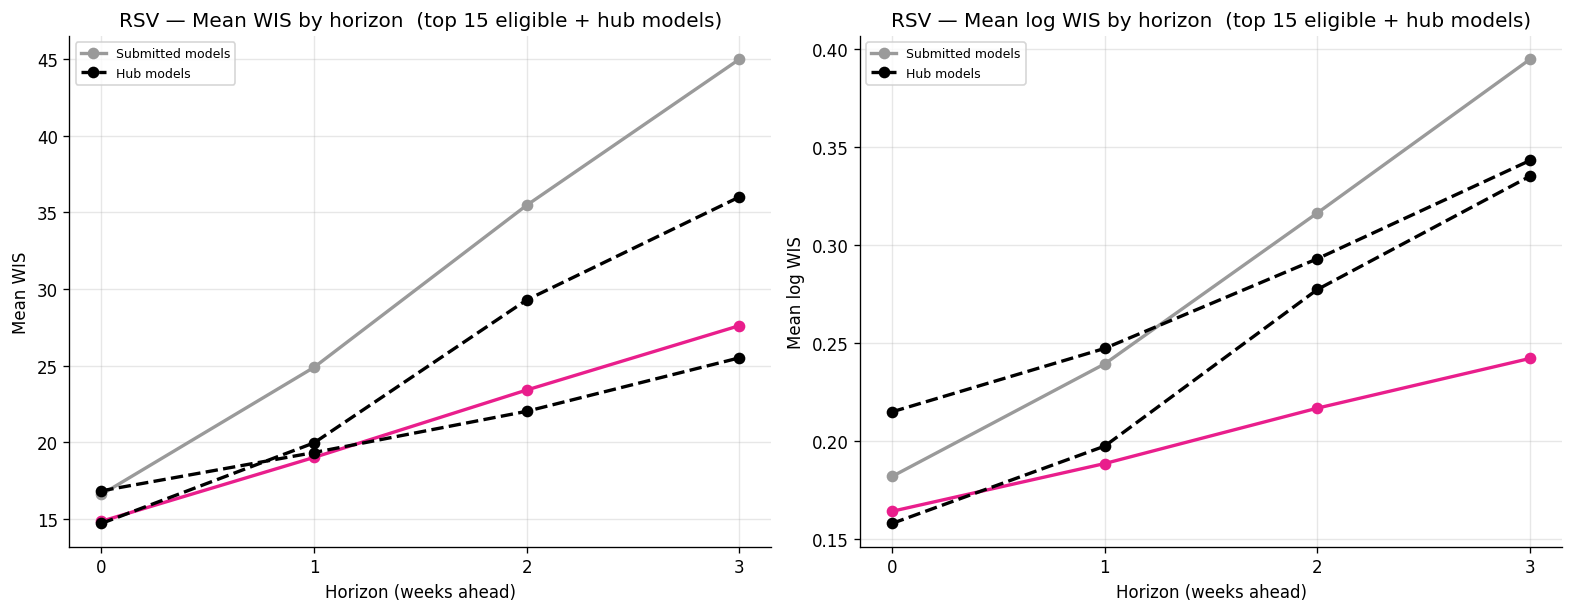

In [24]:
# ── Mean WIS & log WIS by model × horizon (eligible + hub models)
by_hor_wis = (
    elig.groupby(["model_id", "horizon"])["wis"]
    .mean()
    .unstack("horizon")
    .round(2)
)
by_hor_log = (
    elig.groupby(["model_id", "horizon"])["log_wis"]
    .mean()
    .unstack("horizon")
    .round(4)
)

by_hor_wis = by_hor_wis.loc[by_hor_wis.mean(axis=1).sort_values().index]
by_hor_log = by_hor_log.loc[by_hor_log.mean(axis=1).sort_values().index]

print("Mean WIS by model and horizon:")
display(
    by_hor_wis.style
    .background_gradient(cmap="RdYlGn_r", axis=None)
    .format("{:.2f}")
    .apply_index(
        lambda s: [f"color: {GOOGLE_PINK}; font-weight: bold" if v == GOOGLE else "" for v in s],
        axis=0
    )
)

print("\nMean log WIS by model and horizon:")
display(
    by_hor_log.style
    .background_gradient(cmap="RdYlGn_r", axis=None)
    .format("{:.4f}")
    .apply_index(
        lambda s: [f"color: {GOOGLE_PINK}; font-weight: bold" if v == GOOGLE else "" for v in s],
        axis=0
    )
)

P.plot_by_horizon(by_hor_wis, by_hor_log, ALL_HORIZONS, MODEL_COLOUR,
                  hub_models=HUB_MODELS, hub_label=HUB.label)


## Performance over Reference Time

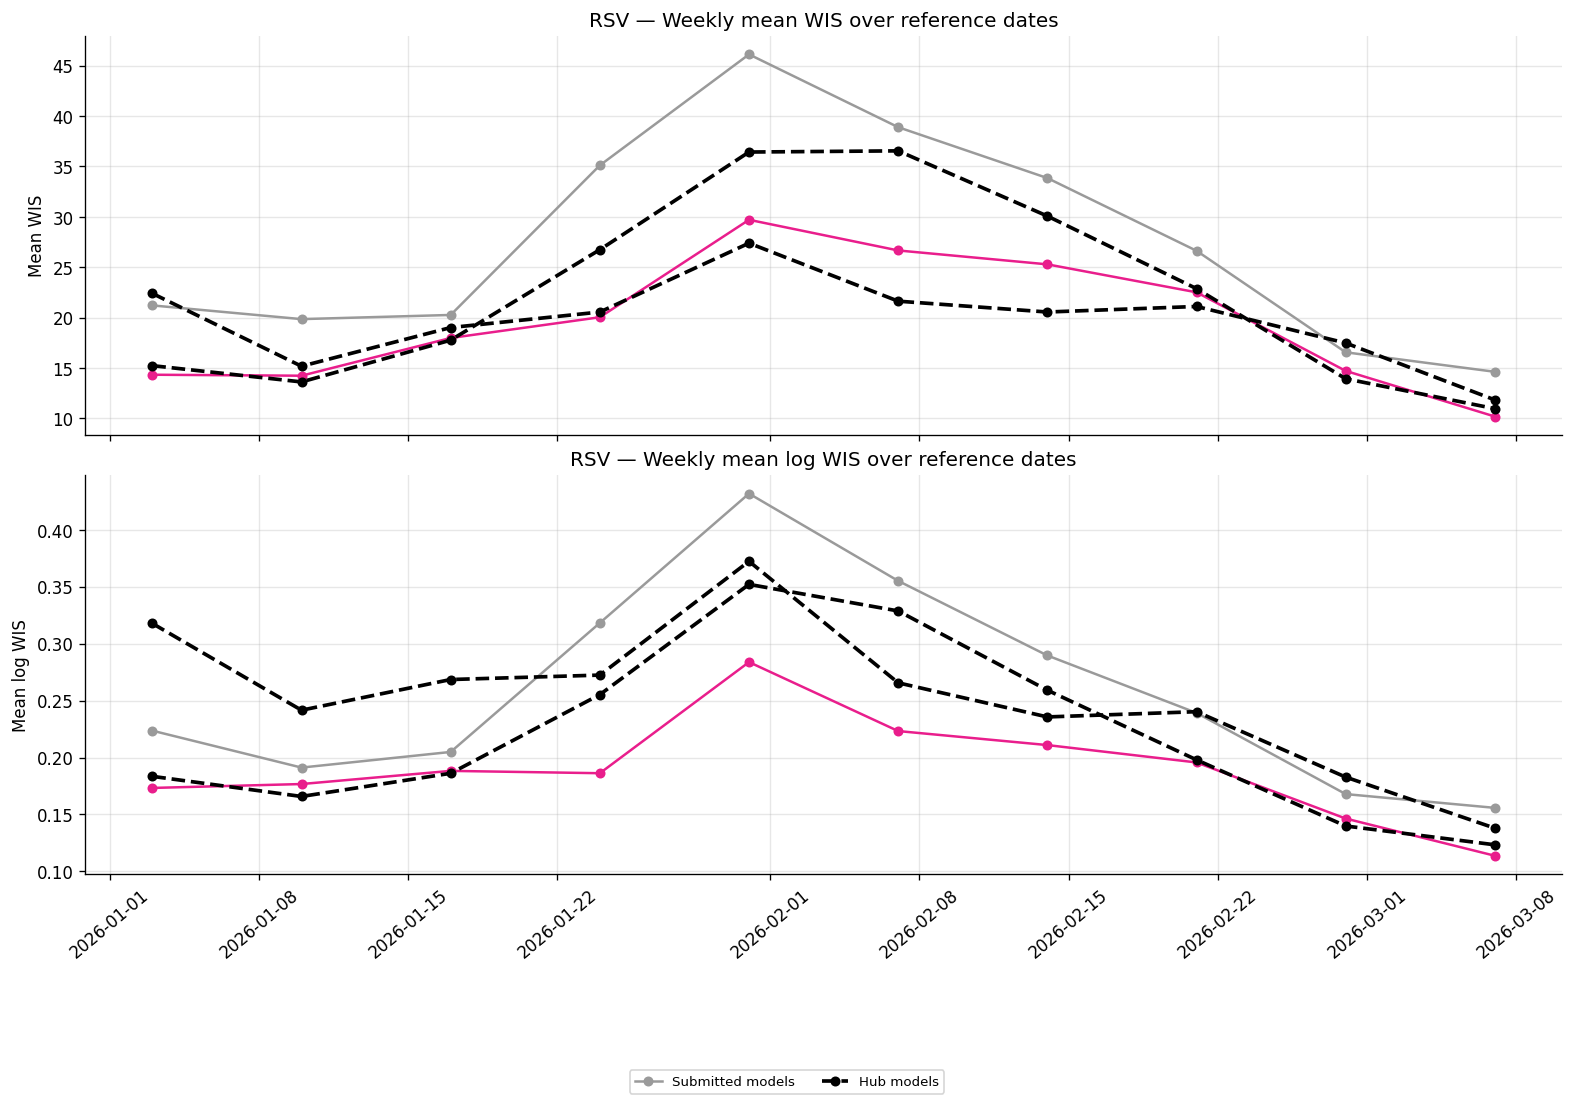

Reference date,Best WIS model,Best WIS,Best log WIS model,Best log WIS
2026-01-03,Google_SAI-RSVEns,14.33,Google_SAI-RSVEns,0.1733
2026-01-10,RSVHub-ensemble,13.62,RSVHub-ensemble,0.1658
2026-01-17,RSVHub-ensemble,17.76,RSVHub-ensemble,0.1861
2026-01-24,Google_SAI-RSVEns,20.04,Google_SAI-RSVEns,0.1862
2026-01-31,RSVHub-baseline,27.38,Google_SAI-RSVEns,0.2838
2026-02-07,RSVHub-baseline,21.63,Google_SAI-RSVEns,0.2232
2026-02-14,RSVHub-baseline,20.55,Google_SAI-RSVEns,0.2109
2026-02-21,RSVHub-baseline,21.10,Google_SAI-RSVEns,0.1957
2026-02-28,RSVHub-ensemble,13.93,RSVHub-ensemble,0.1398
2026-03-07,Google_SAI-RSVEns,10.18,Google_SAI-RSVEns,0.1137


In [25]:
plot_models = sorted(set(eligible_models) | HUB_MODELS)

# Weekly mean WIS / log WIS averaged over horizons and locations
weekly = (
    scores[scores["model_id"].isin(plot_models)]
    .groupby(["model_id", "reference_date"])[["wis", "log_wis"]]
    .mean()
    .reset_index()
)

P.plot_weekly_scores(weekly, plot_models, MODEL_COLOUR, HUB_MODELS, HUB.label)

# Best model by week (eligible only)
weekly_elig = weekly[weekly["model_id"].isin(eligible_models)]

best_wis_idx = weekly_elig.groupby("reference_date")["wis"].idxmin()
best_log_idx = weekly_elig.groupby("reference_date")["log_wis"].idxmin()

best_by_week = pd.DataFrame({
    "Reference date":    weekly_elig.loc[best_wis_idx, "reference_date"].dt.strftime("%Y-%m-%d").values,
    "Best WIS model":    weekly_elig.loc[best_wis_idx, "model_id"].values,
    "Best WIS":          weekly_elig.loc[best_wis_idx, "wis"].values,
    "Best log WIS model":weekly_elig.loc[best_log_idx, "model_id"].values,
    "Best log WIS":      weekly_elig.loc[best_log_idx, "log_wis"].values,
})

display(
    best_by_week.style
    .format({"Best WIS": "{:.2f}", "Best log WIS": "{:.4f}"})
    .hide(axis="index")
    .apply(
        lambda s: [f"color: {GOOGLE_PINK}; font-weight: bold"
                   if v == GOOGLE else "" for v in s],
        subset=["Best WIS model", "Best log WIS model"], axis=0,
    )
)
